# Quick Data Viewer Notebook

In [3]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal


## VNA Sweeps

In [550]:
# list of files in tmp/ sorted by creation time
#tmpfnames = sorted(glob.iglob(os.path.join(os.getcwd()+'/tmp/', 's21_vna*')), 
#                  key=os.path.getctime, reverse=True) 
tmpfnames = sorted(glob.iglob(os.path.join('/home/rfsoc/primecam_readout/src/tmp/', 's21_vna*')), 
                  key=os.path.getctime, reverse=True) 
#tmpfnames = sorted(glob.iglob(os.path.join(os.getcwd()+'/tmp/', 's21_vna_1_1_20221024T162418Z.npy')), 
#                   key=os.path.getctime, reverse=True) 
# latest file
fname = tmpfnames[0]
#fname = r'/s21_vna_1_1_20221024T162418Z.npy'
print(fname)

# assume numpy array and load
dat = np.load(fname, allow_pickle=True)
dat

/home/rfsoc/primecam_readout/src/tmp/s21_vna_1_1_20230516T022041Z.npy


array([[ 3.45345215e+08     +0.j ,  3.45346236e+08     +0.j ,
         3.45347258e+08     +0.j , ...,  8.55252840e+08     +0.j ,
         8.55253861e+08     +0.j ,  8.55254883e+08     +0.j ],
       [-1.76147600e+05+227803.8j, -1.76536600e+05+228637.j ,
        -1.76429800e+05+228700.8j, ...,  2.43017200e+05+103578.j ,
         2.41978400e+05+103189.4j,  2.41970200e+05+103502.2j]])

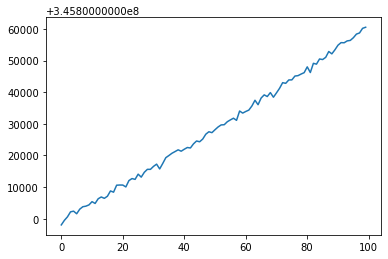

In [551]:
# plt.plot(np.abs(dat[0] + 1j*dat[1])[:967])
plt.plot(np.abs(dat[0] + 1j*dat[1])[700:800])
plt.show()

In [552]:
f,s21 = dat
print(f)
print(s21)

[3.45345215e+08+0.j 3.45346236e+08+0.j 3.45347258e+08+0.j ...
 8.55252840e+08+0.j 8.55253861e+08+0.j 8.55254883e+08+0.j]
[-176147.6+227803.8j -176536.6+228637.j  -176429.8+228700.8j ...
  243017.2+103578.j   241978.4+103189.4j  241970.2+103502.2j]


<IPython.core.display.Javascript object>


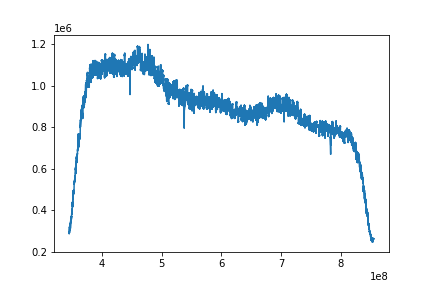

In [553]:
%matplotlib notebook
plt.plot(np.real(f), np.abs(s21))
#plt.xlim(623e6,625e6)
plt.show()

### Old Al Sweep

<IPython.core.display.Javascript object>


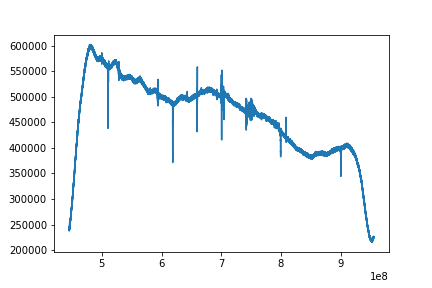

In [327]:
%matplotlib notebook
plt.plot(np.real(f), np.abs(s21))
# plt.xlim(700e6,710e6)
plt.show()

### TiN Sweep (Baseline attenuation)

<IPython.core.display.Javascript object>


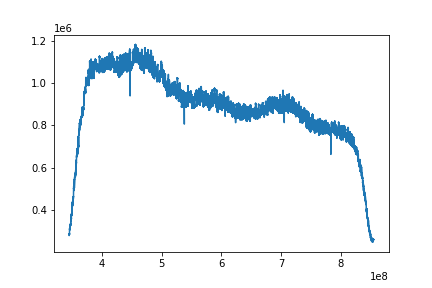

In [330]:
%matplotlib notebook
plt.plot(np.real(f), np.abs(s21))
# plt.xlim(700e6,710e6)
plt.show()

### TiN Sweep (Added 6 dB compared to baseline)

<IPython.core.display.Javascript object>


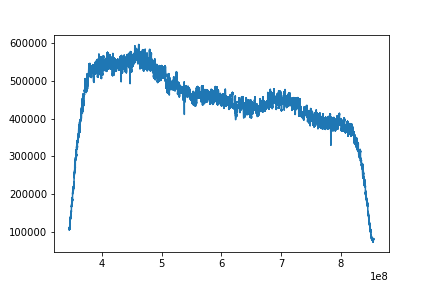

In [333]:
%matplotlib notebook
plt.plot(np.real(f), np.abs(s21))
# plt.xlim(700e6,710e6)
plt.show()

### TiN Sweep (Removed 6 db attenuation rel to baseline)

<IPython.core.display.Javascript object>


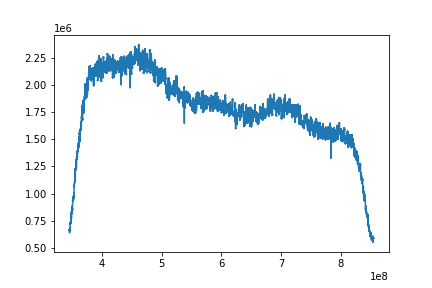

In [336]:
%matplotlib notebook
plt.plot(np.real(f), np.abs(s21))
# plt.xlim(700e6,710e6)
plt.show()

### TiN Sweep (Back to baseline)

<IPython.core.display.Javascript object>


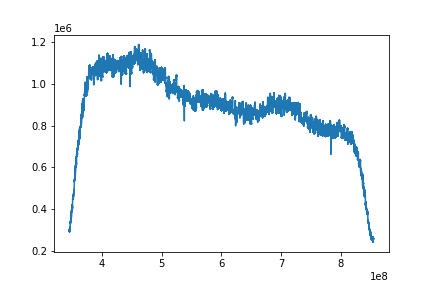

In [343]:
%matplotlib notebook
plt.plot(np.real(f), np.abs(s21))
# plt.xlim(700e6,710e6)
plt.show()

### 04/26/24 TiN Sweep (~100 mK)

<IPython.core.display.Javascript object>


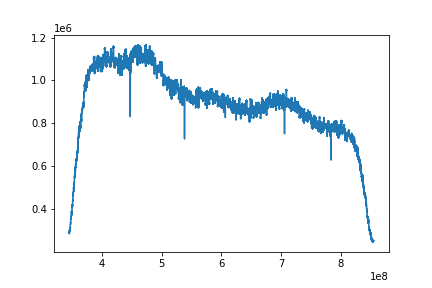

In [467]:
%matplotlib notebook
plt.plot(np.real(f), np.abs(s21))
# plt.xlim(700e6,710e6)
plt.show()

### 04/26/24 TiN Sweep (~120 mK)

<IPython.core.display.Javascript object>


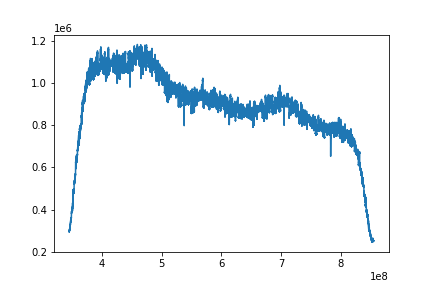

In [486]:
%matplotlib notebook
plt.plot(np.real(f), np.abs(s21))
# plt.xlim(700e6,710e6)
plt.show()

In [309]:

f = np.real(f)
f0 = 704.297e6
ind = np.where(np.abs(f-f0)==np.min(np.abs(f-f0)))[0][0]
N = 40
print(ind)
inds = ind-N
inde = ind+N
I = np.real(s21)
Q = np.imag(s21)
phase = np.arctan2(Q,I)
plt.subplot(131)
plt.plot(np.real(f)[inds:inde],np.abs(s21)[inds:inde])
plt.subplot(132)
plt.plot(I[ind-N:ind+N],Q[ind-N:ind+N])
plt.plot(I[ind],Q[ind],'x')
plt.subplot(133)
plt.plot(np.real(f)[inds:inde],phase[inds:inde])
plt.plot(f[ind],phase[ind],'x')
plt.show()

422370


In [289]:
plt.plot((dat[0][:1024])**2 + (dat[1][:1024])**2)
plt.show()

/home/rfsoc/anaconda3/lib/python3.9/site-packages/matplotlib/cbook/__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


In [282]:
# # visualize data
# plt.imshow(dat)
# plt.colorbar()
# plt.show()

In [265]:
scipy.signal.find_peaks(-np.abs(s21), prominence=1e5)[0]

array([1741])

## Targeted Sweeps

In [4]:
# list of files in tmp/ sorted by creation time
tmpfnames = sorted(glob.iglob(os.path.join('/home/rfsoc/primecam_readout/src/tmp/', 's21_targ*')), 
                   key=os.path.getctime, reverse=True) 

# latest file
fname = tmpfnames[0]
print(fname)

# assume numpy array and load
dat = np.load(fname, allow_pickle=True)
f, s21 = dat
f = np.real(f)

tmpfnames = sorted(glob.iglob(os.path.join('/home/rfsoc/primecam_readout/src/tmp/', 'f_res_targ*')), 
                   key=os.path.getctime, reverse=True) 

# latest file
fname = tmpfnames[0]
print(fname)

# assume numpy array and load
f0s = np.load(fname, allow_pickle=True)


/home/rfsoc/primecam_readout/src/tmp/s21_targ_1_1_20230612T024851Z.npy
/home/rfsoc/primecam_readout/src/tmp/f_res_targ_1_1_20230612T024854Z.npy


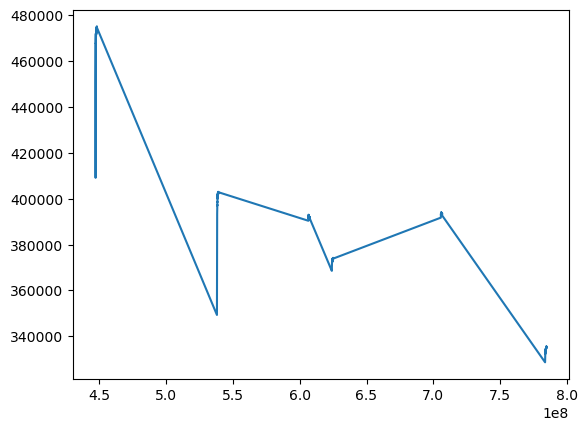

In [5]:
%matplotlib inline 
plt.plot(f,np.abs(s21))
#plt.xlim(4.46e8, 4.48e8)
plt.show()

In [470]:
# p = np.load('/home/rfsoc/rfsoc_result/Steve/230712/20230712_timestream_82mK_source_off.npy')
# b = np.load('/home/rfsoc/rfsoc_result/Steve/230712/20230712_timestream_82mK_source_on.npy')

499


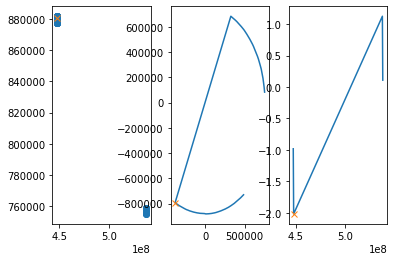

500


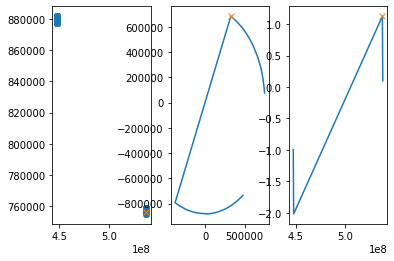

1999


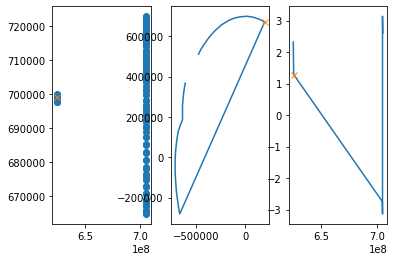

2499


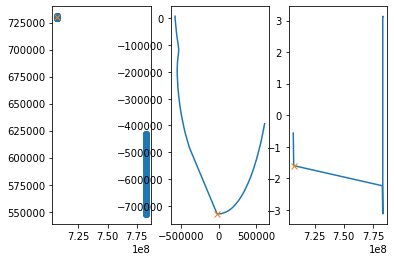

2999


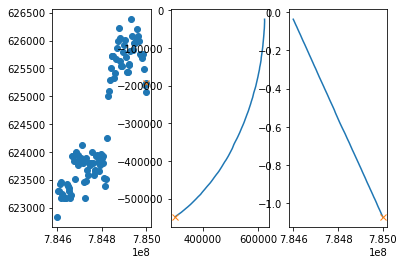

2999


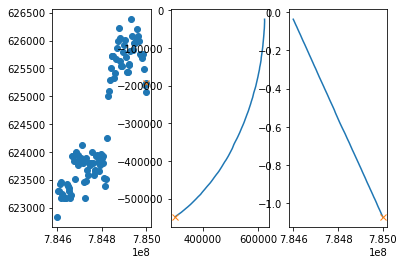

In [549]:
%matplotlib inline 
for i,f0 in enumerate(f0s):
    ind = np.where(np.abs(f-f0)==np.min(np.abs(f-f0)))[0][0]
    N = 100
    print(ind)
    inds = ind-N
    inde = ind+N
    I = np.real(s21)
    Q = np.imag(s21)
    phase = np.arctan2(Q,I)
    plt.subplot(131)
    plt.plot(np.real(f)[inds:inde],np.abs(s21)[inds:inde],'o')
    plt.plot(np.real(f)[ind], np.abs(s21)[ind], 'x')
    plt.subplot(132)
#     plt.plot(p[:, 16+i*2][100:],p[:, 17+i*2][100:],'o',color='m',alpha=0.2)
#     plt.plot(b[:, 16+i*2][100:],b[:, 17+i*2][100:],'o',color='c',alpha=0.2)
    plt.plot(I[ind-N:ind+N],Q[ind-N:ind+N])
    plt.plot(I[ind],Q[ind],'x')
    plt.subplot(133)
    plt.plot(np.real(f)[inds:inde],phase[inds:inde])
    plt.plot(f[ind],phase[ind],'x')
    plt.show()
    


499


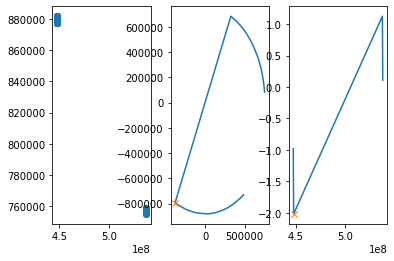

500


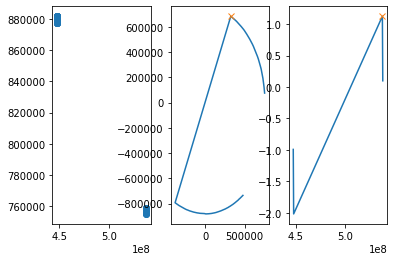

1999


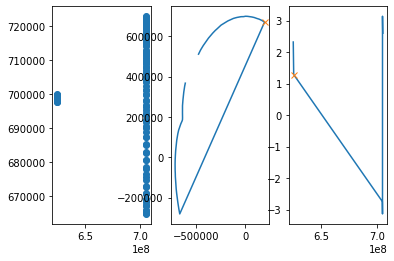

2499


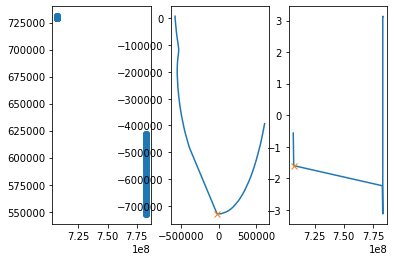

2999


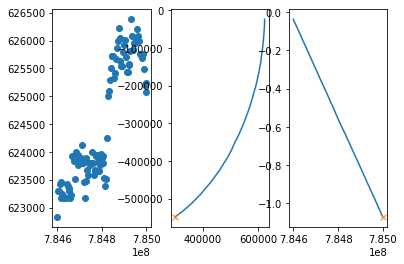

2999


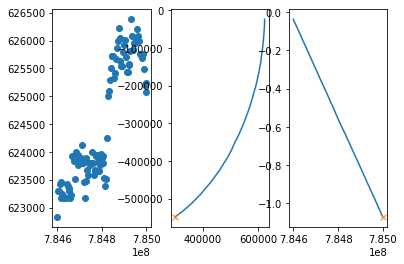

In [499]:
%matplotlib inline 
for i,f0 in enumerate(f0s):
    ind = np.where(np.abs(f-f0)==np.min(np.abs(f-f0)))[0][0]
    N = 100
    print(ind)
    inds = ind-N
    inde = ind+N
    I = np.real(s21)
    Q = np.imag(s21)
    phase = np.arctan2(Q,I)
    plt.subplot(131)
    plt.plot(np.real(f)[inds:inde],np.abs(s21)[inds:inde],'o')
    plt.subplot(132)
#     plt.plot(p[:, 16+i*2][100:],p[:, 17+i*2][100:],'o',color='m',alpha=0.2)
#     plt.plot(b[:, 16+i*2][100:],b[:, 17+i*2][100:],'o',color='c',alpha=0.2)
    plt.plot(I[ind-N:ind+N],Q[ind-N:ind+N])
    plt.plot(I[ind],Q[ind],'x')
    plt.subplot(133)
    plt.plot(np.real(f)[inds:inde],phase[inds:inde])
    plt.plot(f[ind],phase[ind],'x')
    plt.show()

499


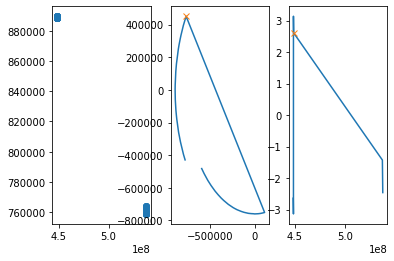

500


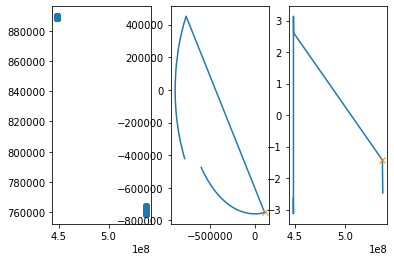

1999


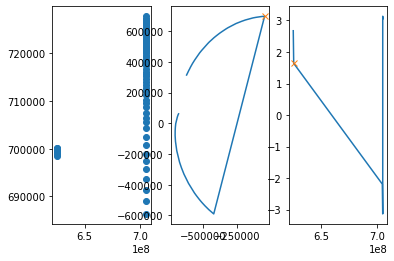

2499


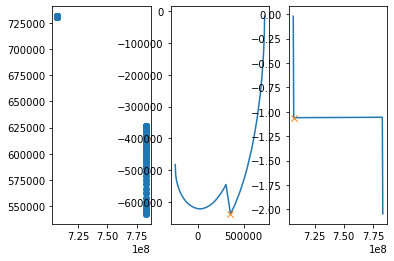

2999


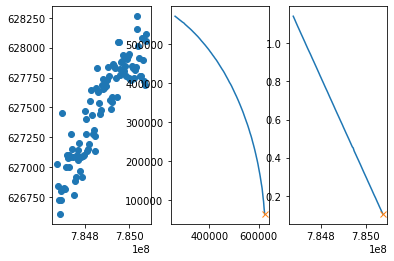

2999


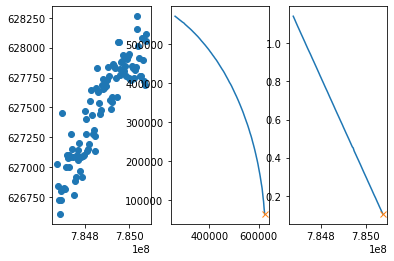

In [474]:
%matplotlib inline 
for i,f0 in enumerate(f0s):
    ind = np.where(np.abs(f-f0)==np.min(np.abs(f-f0)))[0][0]
    N = 100
    print(ind)
    inds = ind-N
    inde = ind+N
    I = np.real(s21)
    Q = np.imag(s21)
    phase = np.arctan2(Q,I)
    plt.subplot(131)
    plt.plot(np.real(f)[inds:inde],np.abs(s21)[inds:inde],'o')
    plt.subplot(132)
#     plt.plot(p[:, 16+i*2][100:],p[:, 17+i*2][100:],'o',color='m',alpha=0.2)
#     plt.plot(b[:, 16+i*2][100:],b[:, 17+i*2][100:],'o',color='c',alpha=0.2)
    plt.plot(I[ind-N:ind+N],Q[ind-N:ind+N])
    plt.plot(I[ind],Q[ind],'x')
    plt.subplot(133)
    plt.plot(np.real(f)[inds:inde],phase[inds:inde])
    plt.plot(f[ind],phase[ind],'x')
    plt.show()
    

In [ ]:
# list of files in tmp/ sorted by creation time
tmpfnames = sorted(glob.iglob(os.path.join(os.getcwd()+'/tmp/', 's21_targ*')), 
                   key=os.path.getctime, reverse=True) 

# latest file
fname = tmpfnames[0]
print(fname)

# assume numpy array and load
dat = np.load(fname, allow_pickle=True)
f, s21 = dat
f = np.real(f)


### 04/26/24 Targ Sweep using findVnaResonators (~100 mK)

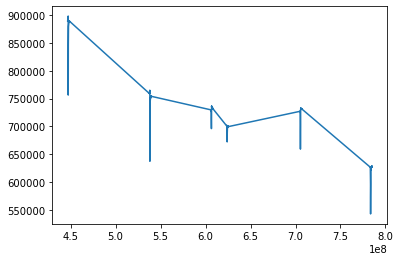

In [481]:
%matplotlib inline 
plt.plot(f,np.abs(s21))
#plt.xlim(7.83e8, 7.84e8)
plt.show()

### 04/26/24 Targ Sweep using findVnaResonators (~120 mK)

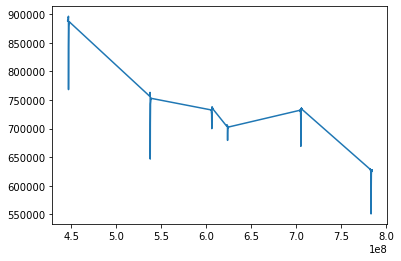

In [491]:
%matplotlib inline 
plt.plot(f,np.abs(s21))
#plt.xlim(7.83e8, 7.84e8)
plt.show()

### 04/26/24 Targ Sweep using Custom Frequencies (~120 mK)

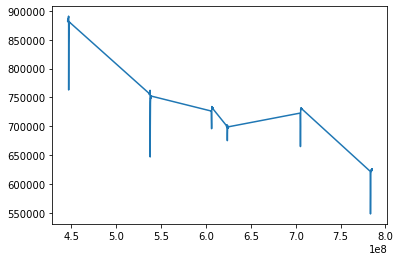

In [497]:
%matplotlib inline 
plt.plot(f,np.abs(s21))
#plt.xlim(7.83e8, 7.84e8)
plt.show()

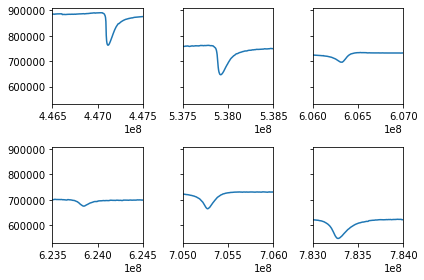

In [544]:
%matplotlib inline 

fig,axs = plt.subplots(nrows = 2, ncols = 3, sharey = True)


axs[0,0].plot(f,np.abs(s21))
axs[0,0].set_xlim(4.465e8, 4.475e8)
axs[0,1].plot(f,np.abs(s21))
axs[0,1].set_xlim(5.375e8, 5.385e8)
axs[0,2].plot(f,np.abs(s21))
axs[0,2].set_xlim(6.06e8, 6.07e8)
axs[1,0].plot(f,np.abs(s21))
axs[1,0].set_xlim(6.235e8, 6.245e8)
axs[1,1].plot(f,np.abs(s21))
axs[1,1].set_xlim(7.05e8, 7.06e8)
axs[1,2].plot(f,np.abs(s21))
axs[1,2].set_xlim(7.83e8, 7.84e8)
plt.tight_layout()
plt.show()

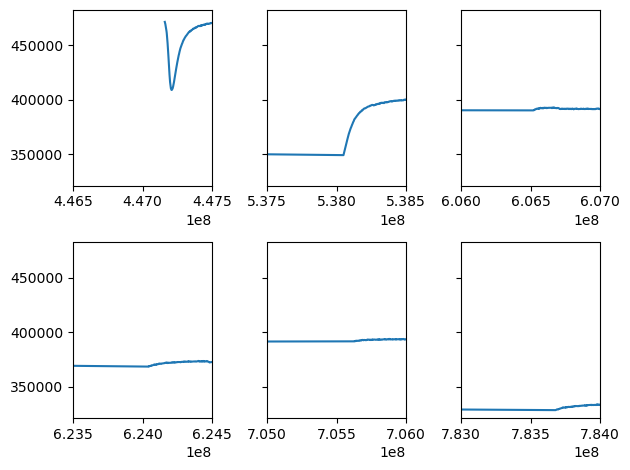

In [6]:
%matplotlib inline 

fig,axs = plt.subplots(nrows = 2, ncols = 3, sharey = True)


axs[0,0].plot(f,np.abs(s21))
axs[0,0].set_xlim(4.465e8, 4.475e8)
axs[0,1].plot(f,np.abs(s21))
axs[0,1].set_xlim(5.375e8, 5.385e8)
axs[0,2].plot(f,np.abs(s21))
axs[0,2].set_xlim(6.06e8, 6.07e8)
axs[1,0].plot(f,np.abs(s21))
axs[1,0].set_xlim(6.235e8, 6.245e8)
axs[1,1].plot(f,np.abs(s21))
axs[1,1].set_xlim(7.05e8, 7.06e8)
axs[1,2].plot(f,np.abs(s21))
axs[1,2].set_xlim(7.83e8, 7.84e8)
plt.tight_layout()
plt.show()